# Prescriptive Analytics for Flight Delay Management

This notebook converts machine learning predictions into actionable operational recommendations.

The objective is to identify high-risk flights and suggest operational actions that may reduce delays and improve airline efficiency.

### Load Dataset

The cleaned flight dataset is loaded from Databricks for prescriptive analysis.

In [0]:
df = spark.table("tables.default.finally_cleaned_data")

display(df.limit(5))

YEAR,MONTH,DAY,DEPARTURE_HOUR,TAIL_NUMBER,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,PEAK_HOUR_INDICATOR,WEEKEND_INDICATOR,ROUTE,IS_DELAYED_DEPARTURE,IS_DELAYED_ARRIVAL,TOTAL_DELAY,DISTANCE_CATEGORY,SEASON,HAS_WEATHER_DELAY,FLIGHTS_PER_TAIL_NUMBER_DAY,FLIGHTS_PER_TAIL_NUMBER_WEEK,ORIGIN_CONGESTION
2015,12,14,17,N527AS,1,AS,474.0,SEA,LAX,1725.0,1721.0,-4.0,12.0,1733.0,159.0,167.0,117.0,954.0,1930.0,38.0,2004.0,2008.0,4.0,0,0,null,0,0,0,0,0,1,0,SEA-LAX,0,0,0.0,Short,Winter,0,5,13,1059
2015,12,14,17,N606JB,1,B6,1684.0,MCO,JFK,1725.0,1809.0,44.0,17.0,1826.0,156.0,158.0,126.0,944.0,2032.0,15.0,2001.0,2047.0,46.0,0,0,null,46,0,0,0,0,1,0,MCO-JFK,1,1,90.0,Short,Winter,0,3,13,1059
2015,12,14,17,N345NW,1,DL,855.0,DTW,SLC,1725.0,1729.0,4.0,19.0,1748.0,242.0,238.0,210.0,1481.0,1918.0,9.0,1927.0,1927.0,0.0,0,0,null,0,0,0,0,0,1,0,DTW-SLC,0,0,4.0,Medium,Winter,0,3,12,1059
2015,12,14,17,N676DL,1,DL,1088.0,MSP,ANC,1725.0,1741.0,16.0,15.0,1756.0,373.0,338.0,317.0,2519.0,2013.0,6.0,2038.0,2019.0,-19.0,0,0,null,0,0,0,0,0,1,0,MSP-ANC,1,0,-3.0,Long,Winter,0,4,19,1059
2015,12,14,17,N310NW,1,DL,1267.0,ATL,DTW,1725.0,1727.0,2.0,17.0,1744.0,115.0,113.0,89.0,594.0,1913.0,7.0,1920.0,1920.0,0.0,0,0,null,0,0,0,0,0,1,0,ATL-DTW,0,0,2.0,Short,Winter,0,5,18,1059


### Feature Engineering

Additional variables are created so that the prescriptive dataset matches the same feature structure used in the machine learning model.

IS_LONG_DISTANCE identifies flights with long travel distance.

IS_EVENING identifies flights departing during evening hours.

HAS_DELAY_CAUSE captures whether operational delay causes were reported.

In [0]:
pdf = df.sample(fraction=0.2).toPandas()

In [0]:
from pyspark.sql import functions as F

df = df.withColumn(
    "IS_LONG_DISTANCE",
    F.when(F.col("DISTANCE") > 1500, 1).otherwise(0)
)

df = df.withColumn(
    "IS_EVENING",
    F.when(F.col("DEPARTURE_HOUR") >= 18, 1).otherwise(0)
)

df = df.withColumn(
    "HAS_DELAY_CAUSE",
    F.when(
        (F.col("AIRLINE_DELAY") > 0) |
        (F.col("WEATHER_DELAY") > 0) |
        (F.col("AIR_SYSTEM_DELAY") > 0) |
        (F.col("LATE_AIRCRAFT_DELAY") > 0),
        1
    ).otherwise(0)
)

### Convert Data to Pandas

The prepared Spark DataFrame is converted into a Pandas DataFrame so that the trained Scikit-learn model can be used for prediction.

In [0]:
pdf = df.sample(fraction=0.2).toPandas()

print("Dataset shape:", pdf.shape)
pdf.head()

Dataset shape: (1163732, 47)


,YEAR,MONTH,DAY,DEPARTURE_HOUR,TAIL_NUMBER,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,PEAK_HOUR_INDICATOR,WEEKEND_INDICATOR,ROUTE,IS_DELAYED_DEPARTURE,IS_DELAYED_ARRIVAL,TOTAL_DELAY,DISTANCE_CATEGORY,SEASON,HAS_WEATHER_DELAY,FLIGHTS_PER_TAIL_NUMBER_DAY,FLIGHTS_PER_TAIL_NUMBER_WEEK,ORIGIN_CONGESTION,IS_LONG_DISTANCE,IS_EVENING,HAS_DELAY_CAUSE
0,2015,4,1,10,N371SW,3,WN,48.0,PHX,MSY,1015.0,1020.0,5.0,15.0,1035.0,175.0,173.0,153.0,1300.0,1508.0,5.0,1510.0,1513.0,3.0,0,0,null,0,0,0,0,0,0,0,PHX-MSY,0,0,8.0,Medium,Spring,0,5,33,1068,0,0,0
1,2015,4,1,10,N352SW,3,WN,1.0,SAT,ELP,1015.0,1012.0,-3.0,7.0,1019.0,95.0,88.0,78.0,496.0,1037.0,3.0,1050.0,1040.0,-10.0,0,0,null,0,0,0,0,0,0,0,SAT-ELP,0,0,-13.0,Short,Spring,0,8,25,1068,0,0,0
2,2015,4,1,10,N495WN,3,WN,1628.0,DEN,BWI,1015.0,1013.0,-2.0,23.0,1036.0,200.0,201.0,173.0,1491.0,1529.0,5.0,1535.0,1534.0,-1.0,0,0,null,0,0,0,0,0,0,0,DEN-BWI,0,0,-3.0,Medium,Spring,0,5,30,1068,0,0,0
3,2015,4,1,10,N629SW,3,WN,321.0,STL,DAL,1015.0,1043.0,28.0,8.0,1051.0,100.0,94.0,82.0,546.0,1213.0,4.0,1155.0,1217.0,22.0,0,0,null,0,0,22,0,0,0,0,STL-DAL,1,1,50.0,Short,Spring,0,5,36,1068,0,0,1
4,2015,4,1,10,N622SW,3,WN,655.0,HOU,TPA,1015.0,1119.0,64.0,6.0,1125.0,115.0,106.0,94.0,781.0,1359.0,6.0,1310.0,1405.0,55.0,0,0,null,0,0,0,55,0,0,0,HOU-TPA,1,1,119.0,Short,Spring,0,5,37,1068,0,0,1


### Feature Definition

The same input variables used during machine learning training are selected for prediction.

In [0]:
features = [
    "DISTANCE",
    "DEPARTURE_HOUR",
    "DAY_OF_WEEK",
    "ORIGIN_CONGESTION",
    "IS_LONG_DISTANCE",
    "IS_EVENING",
    "HAS_DELAY_CAUSE",
    "FLIGHTS_PER_TAIL_NUMBER_DAY",
    "FLIGHTS_PER_TAIL_NUMBER_WEEK"
]

### Data Cleaning for Prediction

Some values may appear as text or invalid entries. These are converted into numeric format to ensure compatibility with the trained machine learning model.

In [0]:
import pandas as pd
import numpy as np

for col in features:
    pdf[col] = pd.to_numeric(pdf[col], errors="coerce")

pdf = pdf.dropna(subset=features)

print("Cleaned dataset shape:", pdf.shape)
pdf[features].dtypes

Cleaned dataset shape: (1160677, 47)


DISTANCE                        float64
DEPARTURE_HOUR                    int64
DAY_OF_WEEK                     float64
ORIGIN_CONGESTION                 int64
IS_LONG_DISTANCE                  int32
IS_EVENING                        int32
HAS_DELAY_CAUSE                   int32
FLIGHTS_PER_TAIL_NUMBER_DAY     float64
FLIGHTS_PER_TAIL_NUMBER_WEEK    float64
dtype: object

### Delay Probability Prediction

The trained Random Forest model is used to estimate the probability that each flight will experience an arrival delay.

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

target = "IS_DELAYED_ARRIVAL"

# features already defined
X = pdf[features]
y = pdf[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150, random_state=42)

In [0]:
pdf["delay_probability"] = rf_model.predict_proba(pdf[features])[:,1]

pdf[["delay_probability"]].head()

,delay_probability
0,0.000000
1,0.000000
2,0.000000
3,0.986667
4,0.953333


### Risk Classification

Flights are grouped into Low Risk, Medium Risk, and High Risk categories based on predicted delay probability.

In [0]:
def classify_risk(prob):
    if prob > 0.75:
        return "High Risk"
    elif prob > 0.50:
        return "Medium Risk"
    else:
        return "Low Risk"

pdf["risk_level"] = pdf["delay_probability"].apply(classify_risk)

pdf[["delay_probability", "risk_level"]].head()

,delay_probability,risk_level
0,0.000000,Low Risk
1,0.000000,Low Risk
2,0.000000,Low Risk
3,0.986667,High Risk
4,0.953333,High Risk


### Prescriptive Recommendation Logic

Operational recommendations are generated based on the estimated risk level.

High Risk flights receive more proactive operational intervention.

Medium Risk flights are monitored closely.

Low Risk flights follow normal operations.

In [0]:
def recommend_action(risk):
    if risk == "High Risk":
        return "Assign priority gate and backup crew"
    elif risk == "Medium Risk":
        return "Monitor operations and prepare support"
    else:
        return "Normal operation"

pdf["recommended_action"] = pdf["risk_level"].apply(recommend_action)

pdf[["risk_level", "recommended_action"]].head()

,risk_level,recommended_action
0,Low Risk,Normal operation
1,Low Risk,Normal operation
2,Low Risk,Normal operation
3,High Risk,Assign priority gate and backup crew
4,High Risk,Assign priority gate and backup crew


### Final Recommendation Table

This table summarizes predicted delay probability, assigned risk level, and operational recommendation for each flight.

In [0]:
recommendation_table = pdf[[
    "delay_probability",
    "risk_level",
    "recommended_action"
]]

recommendation_table.head(10)

,delay_probability,risk_level,recommended_action
0,0.000000,Low Risk,Normal operation
1,0.000000,Low Risk,Normal operation
2,0.000000,Low Risk,Normal operation
3,0.986667,High Risk,Assign priority gate and backup crew
4,0.953333,High Risk,Assign priority gate and backup crew
5,0.000000,Low Risk,Normal operation
6,0.000000,Low Risk,Normal operation
7,0.000000,Low Risk,Normal operation
8,0.000000,Low Risk,Normal operation
9,0.000000,Low Risk,Normal operation


### Enhanced Recommendation Table

Additional operational fields are included to make the recommendation output more useful for decision-making.

In [0]:
business_cols = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "DEPARTURE_HOUR",
    "DISTANCE"
]

available_cols = [c for c in business_cols if c in pdf.columns]

recommendation_table_full = pdf[available_cols + [
    "delay_probability",
    "risk_level",
    "recommended_action"
]]

recommendation_table_full.head(10)

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_HOUR,DISTANCE,delay_probability,risk_level,recommended_action
0,WN,PHX,MSY,10,1300.0,0.000000,Low Risk,Normal operation
1,WN,SAT,ELP,10,496.0,0.000000,Low Risk,Normal operation
2,WN,DEN,BWI,10,1491.0,0.000000,Low Risk,Normal operation
3,WN,STL,DAL,10,546.0,0.986667,High Risk,Assign priority gate and backup crew
4,WN,HOU,TPA,10,781.0,0.953333,High Risk,Assign priority gate and backup crew
5,DL,MSP,PHL,10,980.0,0.000000,Low Risk,Normal operation
6,DL,SAV,ATL,10,214.0,0.000000,Low Risk,Normal operation
7,DL,GPT,ATL,10,352.0,0.000000,Low Risk,Normal operation
8,EV,GRB,ORD,10,173.0,0.000000,Low Risk,Normal operation
9,EV,GSP,ORD,10,578.0,0.000000,Low Risk,Normal operation


### Risk Distribution Visualization

The following chart shows how flights are distributed across the three risk categories.

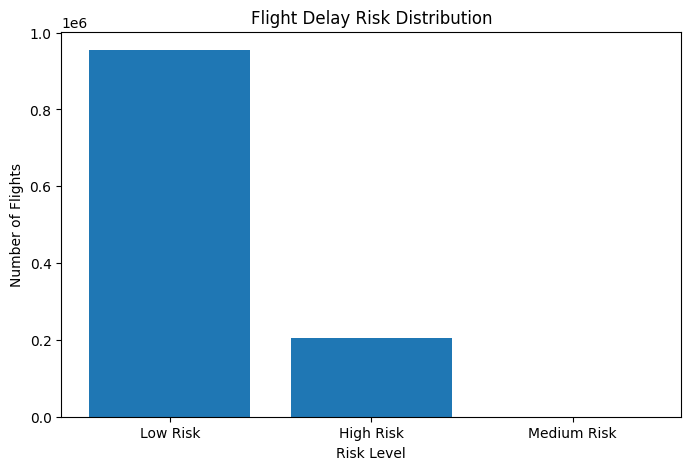

In [0]:
import matplotlib.pyplot as plt

risk_counts = pdf["risk_level"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(risk_counts.index, risk_counts.values)
plt.title("Flight Delay Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Flights")
plt.show()

### High-Risk Flights

The flights with the highest predicted delay probability are displayed below.

In [0]:
top_high_risk = recommendation_table_full.sort_values(
    by="delay_probability",
    ascending=False
).head(20)

top_high_risk

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_HOUR,DISTANCE,delay_probability,risk_level,recommended_action
270605,DL,ATL,PHL,11,666.0,1.0,High Risk,Assign priority gate and backup crew
270407,UA,DEN,LGA,10,1620.0,1.0,High Risk,Assign priority gate and backup crew
117465,DL,ATL,DCA,7,547.0,1.0,High Risk,Assign priority gate and backup crew
117464,DL,SFO,ATL,7,2139.0,1.0,High Risk,Assign priority gate and backup crew
1132304,AA,CLT,MCO,9,468.0,1.0,High Risk,Assign priority gate and backup crew
270381,EV,ATL,CRW,10,363.0,1.0,High Risk,Assign priority gate and backup crew
945401,AA,ELP,DFW,7,551.0,1.0,High Risk,Assign priority gate and backup crew
760810,DL,SAN,SLC,18,626.0,1.0,High Risk,Assign priority gate and backup crew
760813,US,PHL,SJU,18,1576.0,1.0,High Risk,Assign priority gate and backup crew
760815,WN,BWI,IND,18,516.0,1.0,High Risk,Assign priority gate and backup crew


### Prescriptive Analytics Summary

Prescriptive analytics was implemented to translate machine learning predictions into actionable operational decisions for airline delay management.

Using the trained Random Forest model, delay probabilities were generated for each flight based on operational features such as departure hour, flight distance, airport congestion, and aircraft utilization patterns.

Flights were categorized into three risk levels: **Low Risk**, **Medium Risk**, and **High Risk** according to their predicted delay probability. This classification helps airline operations teams identify potential delays before they occur.

Based on the risk level, operational recommendations were generated.  
- **High Risk flights** were assigned proactive actions such as priority gate allocation and backup crew planning.  
- **Medium Risk flights** were flagged for operational monitoring and preparation of supporting resources.  
- **Low Risk flights** continued under normal operational procedures.

A final recommendation table was produced summarizing delay probability, risk classification, and recommended operational actions for each flight.

This prescriptive analytics framework allows airlines to move from reactive delay management toward **proactive operational planning**, which can improve on-time performance and reduce operational disruptions.